# MM26 Machine Learning Model Walkthrough

## The "Cinderella System"

This notebook walks through, step by step, how the machine learning pipeline powering our March Madness predictions works. The thesis is the **Cinderella System** — a model that identifies teams *outperforming expectations* using a "heat" variable, then blends that with traditional ELO-based predictions and Monte Carlo bracket simulations.

### How It Works

1. **ELO Engine** — Establish baseline expectations for every team using game-by-game ELO ratings
2. **Heat Variable** — Compare actual performance to ELO expectations over 1, 3, and 5-game windows
3. **Feature Engineering** — Build 12 pairwise difference features for every possible matchup
4. **XGBoost Model** — Train a gradient-boosted classifier on historical tournament outcomes
5. **Monte Carlo Simulation** — Run 100,000 bracket simulations to produce consensus predictions
6. **Blend** — Combine XGBoost model predictions with simulation predictions (you can tune the weights!)

### Where the Submission Lives

The final Kaggle submission file is at: **`artifacts/latest/submission.csv`**

Format: `ID,Pred` where `ID = Season_TeamLow_TeamHigh` and `Pred = P(TeamLow wins)`.

---

In [15]:
from __future__ import annotations
import json, sys
from pathlib import Path
import numpy as np
import polars as pl

# Add project root to path so we can import pipeline helpers
ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "src"))

BASE = ROOT / "artifacts" / "latest"

# Load run manifest and model diagnostics
manifest = json.loads((BASE / "run_manifest.json").read_text(encoding="utf-8"))
perf = json.loads((BASE / "reports" / "model_performance_summary.json").read_text(encoding="utf-8"))

# Load gold-layer artifacts
elo_ratings = pl.read_parquet(BASE / "gold" / "elo_ratings.parquet")
heat_scores = pl.read_parquet(BASE / "gold" / "heat_scores.parquet")
team_features = pl.read_parquet(BASE / "gold" / "team_season_features.parquet")
pairwise_features = pl.read_parquet(BASE / "gold" / "pairwise_features.parquet")
submission = pl.read_csv(BASE / "submission.csv")

# Load team names for display
teams = pl.read_csv(ROOT / "data" / "MTeams.csv").select("TeamID", "TeamName")
seeds_all = pl.read_csv(ROOT / "data" / "MNCAATourneySeeds.csv")
seeds_2026 = seeds_all.filter(pl.col("Season") == 2026)
slots_2026 = pl.read_csv(ROOT / "data" / "MNCAATourneySlots.csv").filter(pl.col("Season") == 2026)

# Optional: matplotlib for charts
try:
    import matplotlib.pyplot as plt
    HAS_PLT = True
except ImportError:
    HAS_PLT = False
    print("matplotlib not installed — charts will be skipped")

print(f"Run ID        : {manifest['run_id']}")
print(f"Target season : {manifest['target_season']}")
print(f"Model type    : {perf['model_stats']['M']['model_type']}")
print(f"Holdout Brier : {perf['model_stats']['M']['holdout_brier']:.4f}")
print(f"Simulation    : {perf['simulation']['simulated']} ({perf['simulation'].get('M_matchups_simulated', 0)} M matchups)")
print(f"\nGold artifacts loaded:")
print(f"  elo_ratings      : {elo_ratings.shape}")
print(f"  heat_scores      : {heat_scores.shape}")
print(f"  team_features    : {team_features.shape}")
print(f"  pairwise_features: {pairwise_features.shape}")
print(f"  submission       : {submission.shape}")

Run ID        : 20260318T034334Z_2279656a
Target season : 2026
Model type    : xgboost
Holdout Brier : 0.1660
Simulation    : True (200 M matchups)

Gold artifacts loaded:
  elo_ratings      : (423432, 11)
  heat_scores      : (423432, 8)
  team_features    : (14311, 19)
  pairwise_features: (132133, 53)
  submission       : (132133, 2)


---

## Step 1 — The ELO Engine

ELO is a rating system originally designed for chess. Every team starts at **1500** each season. After each game, ratings shift based on the result vs. expectations:

- **K-factor = 20** — how much ratings shift per game
- **Expected win probability**: $P(\text{low wins}) = \frac{1}{1 + 10^{-(\text{ELO}_\text{low} - \text{ELO}_\text{high}) / 400}}$
- **Expected margin**: $25 \times (2 \times P(\text{low wins}) - 1)$

A team that beats a much higher-rated opponent will gain more ELO than one that beats a weaker opponent. By season's end, the top ELO teams are the ones that have *consistently performed well against quality opponents*.

Let's look at how ELO evolved for a few 2026 tournament teams:

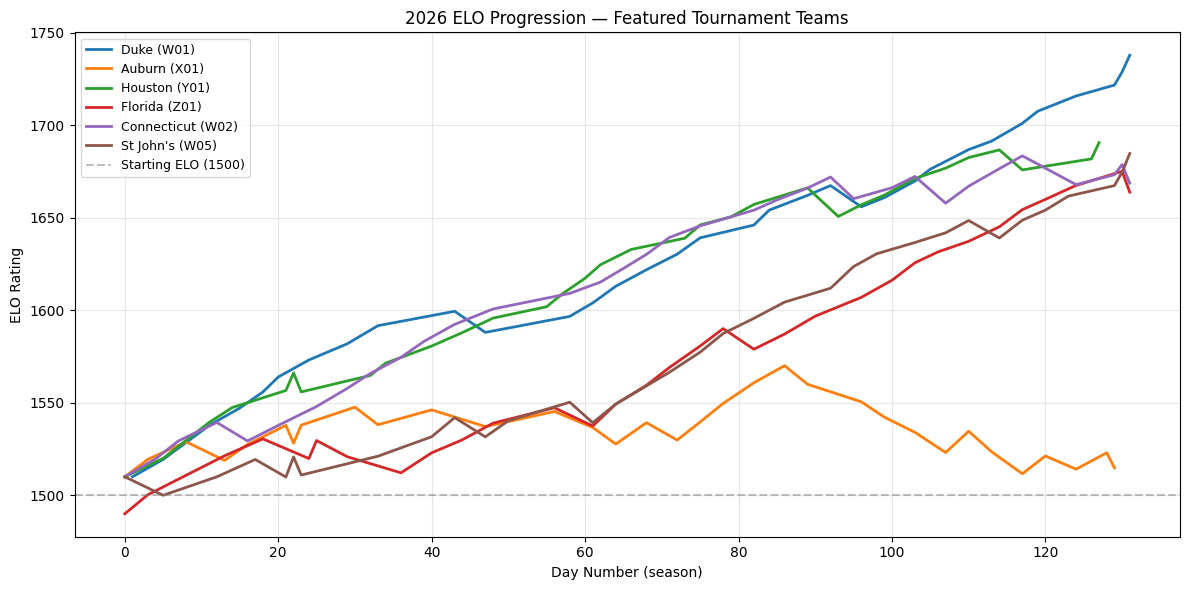

In [16]:
# ELO progression for featured 2026 tournament teams
FEATURED_TEAMS = {
    1181: "Duke (W01)",
    1120: "Auburn (X01)",
    1211: "Houston (Y01)",
    1196: "Florida (Z01)",
    1163: "Connecticut (W02)",
    1385: "St John's (W05)",
}

elo_2026 = elo_ratings.filter(
    (pl.col("sex") == "M") & (pl.col("season") == 2026)
)

if HAS_PLT:
    fig, ax = plt.subplots(figsize=(12, 6))
    for tid, label in FEATURED_TEAMS.items():
        team_elo = elo_2026.filter(pl.col("team_id") == tid).sort("day_num")
        if team_elo.height > 0:
            ax.plot(
                team_elo["day_num"].to_numpy(),
                team_elo["elo_after"].to_numpy(),
                label=label, linewidth=2,
            )
    ax.axhline(y=1500, color="gray", linestyle="--", alpha=0.5, label="Starting ELO (1500)")
    ax.set_xlabel("Day Number (season)")
    ax.set_ylabel("ELO Rating")
    ax.set_title("2026 ELO Progression — Featured Tournament Teams")
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    # Text fallback
    for tid, label in FEATURED_TEAMS.items():
        team_elo = elo_2026.filter(pl.col("team_id") == tid).sort("day_num")
        if team_elo.height > 0:
            final_elo = team_elo["elo_after"][-1]
            print(f"  {label:25s} → Final ELO: {final_elo:.1f}")

In [17]:
# Top 20 teams by season-end ELO for 2026 Men's tournament
m_2026_features = team_features.filter(
    (pl.col("sex") == "M") & (pl.col("season") == 2026)
)

# Join with seeds and team names
tourney_teams = (
    m_2026_features
    .join(seeds_2026.select(
        pl.col("TeamID").cast(pl.Int64).alias("team_id"),
        pl.col("Seed"),
    ), on="team_id", how="inner")
    .join(teams.rename({"TeamID": "team_id"}), on="team_id", how="left")
    .with_columns(
        pl.col("Seed").str.extract(r"(\d+)", 1).cast(pl.Int64).alias("seed_num"),
    )
    .sort("season_end_elo", descending=True)
)

print("Top 20 Teams by ELO — 2026 Men's Tournament\n")
print(f"{'Seed':<6} {'Team':<22} {'ELO':>8} {'Win Rate':>10} {'Record':>10}")
print("─" * 60)
for row in tourney_teams.head(20).iter_rows(named=True):
    record = f"{row['wins']}-{row['losses']}"
    print(f"{row['Seed']:<6} {row['TeamName']:<22} {row['season_end_elo']:>8.1f} {row['win_rate']:>9.1%} {record:>10}")

Top 20 Teams by ELO — 2026 Men's Tournament

Seed   Team                        ELO   Win Rate     Record
────────────────────────────────────────────────────────────
W01    Duke                     1737.9     94.1%       32-2
Z01    Arizona                  1732.0     94.1%       32-2
Y01    Michigan                 1716.4     91.2%       31-3
Z03    Gonzaga                  1690.7     90.9%       30-3
Y03    Virginia                 1686.5     85.3%       29-5
W05    St John's                1684.8     82.4%       28-6
Y11a   Miami OH                 1677.2     96.6%       28-1
W02    Connecticut              1668.7     85.3%       29-5
X02    Houston                  1665.7     82.4%       28-6
X01    Florida                  1663.9     78.8%       26-7
X11    VCU                      1663.3     79.4%       27-7
Y12    Akron                    1659.9     84.4%       27-5
X07    St Mary's CA             1658.4     83.9%       26-5
Z09    Utah St                  1652.4     81.8%     

---

## Step 2 — The Heat Variable (Cinderella Detection)

The **heat variable** is the core innovation. It measures how much a team is *outperforming their ELO-based expectations*:

$$\text{heat\_delta} = \text{actual\_margin} - \text{expected\_margin}$$

We compute rolling averages over three lookback windows:
- **heat_1g** — Last 1 game (most recent momentum)
- **heat_3g** — Average of last 3 games (short-term trend)
- **heat_5g** — Average of last 5 games (sustained over-performance)

A team with **positive heat** heading into the tournament is winning by *more* than their ELO predicts — they're "hot." A team with **negative heat** is underperforming expectations — they're "cold."

The hypothesis: **hot teams are more likely to pull upsets**, and this signal improves our predictions beyond what traditional stats capture.

In [18]:
# Show the hottest and coldest teams entering the 2026 Men's tournament
heat_display = (
    tourney_teams
    .select("Seed", "TeamName", "season_end_elo", "pre_tourney_heat_1g", "pre_tourney_heat_3g", "pre_tourney_heat_5g")
)

print("🔥 HOTTEST Teams (by 5-game heat) entering 2026 Tournament\n")
print(f"{'Seed':<6} {'Team':<22} {'ELO':>7} {'Heat 1g':>9} {'Heat 3g':>9} {'Heat 5g':>9}")
print("─" * 65)
hot = heat_display.sort("pre_tourney_heat_5g", descending=True).head(10)
for row in hot.iter_rows(named=True):
    h1 = row["pre_tourney_heat_1g"] or 0
    h3 = row["pre_tourney_heat_3g"] or 0
    h5 = row["pre_tourney_heat_5g"] or 0
    print(f"{row['Seed']:<6} {row['TeamName']:<22} {row['season_end_elo']:>7.1f} {h1:>+9.2f} {h3:>+9.2f} {h5:>+9.2f}")

print("\n\n❄️  COLDEST Teams (by 5-game heat) entering 2026 Tournament\n")
print(f"{'Seed':<6} {'Team':<22} {'ELO':>7} {'Heat 1g':>9} {'Heat 3g':>9} {'Heat 5g':>9}")
print("─" * 65)
cold = heat_display.sort("pre_tourney_heat_5g", descending=False).head(10)
for row in cold.iter_rows(named=True):
    h1 = row["pre_tourney_heat_1g"] or 0
    h3 = row["pre_tourney_heat_3g"] or 0
    h5 = row["pre_tourney_heat_5g"] or 0
    print(f"{row['Seed']:<6} {row['TeamName']:<22} {row['season_end_elo']:>7.1f} {h1:>+9.2f} {h3:>+9.2f} {h5:>+9.2f}")

🔥 HOTTEST Teams (by 5-game heat) entering 2026 Tournament

Seed   Team                       ELO   Heat 1g   Heat 3g   Heat 5g
─────────────────────────────────────────────────────────────────
Y15    Tennessee St            1580.8    +11.29    +14.31    +15.27
Y16a   Howard                  1553.6     +7.79     +6.95    +13.72
Y16b   UMBC                    1589.3    +14.24    +16.82    +13.71
X16b   Prairie View            1484.4    +20.57    +11.71    +13.51
X01    Florida                 1663.9     +2.05     +8.60    +13.13
W11    South Florida           1634.7    +14.25     +8.85    +11.98
X02    Houston                 1665.7    +19.20     +7.15    +11.63
Y02    Iowa St                 1644.5    +19.95    +25.42    +10.78
W01    Duke                    1737.9     +4.70     +2.02    +10.28
W13    Cal Baptist             1615.9     +8.98    +11.52     +9.57


❄️  COLDEST Teams (by 5-game heat) entering 2026 Tournament

Seed   Team                       ELO   Heat 1g   Heat 3g   Heat

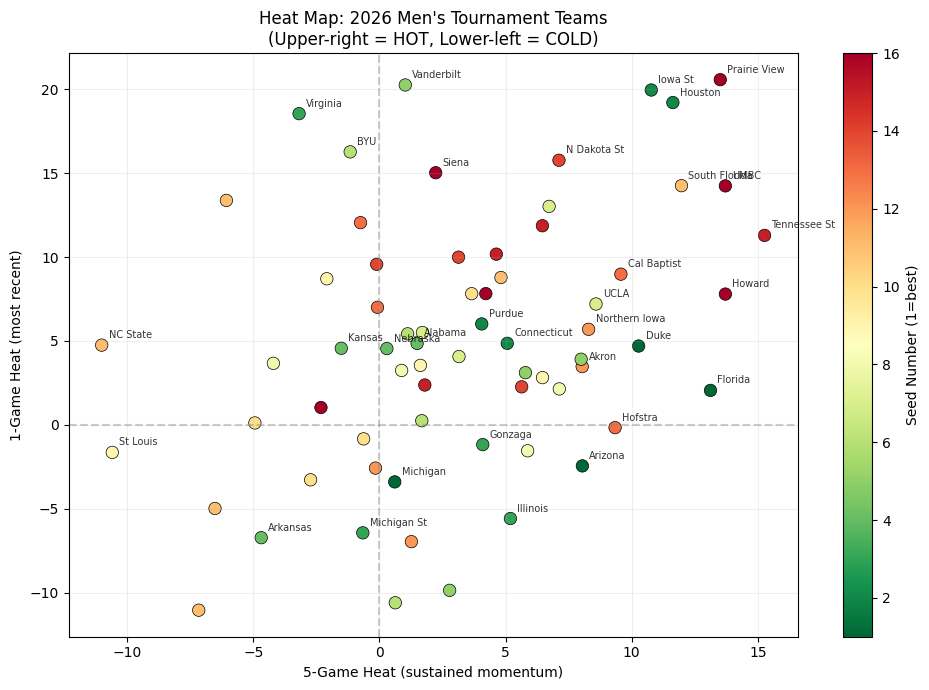

In [19]:
# Heat distribution scatter: 1-game vs 5-game heat for all 2026 M tourney teams
if HAS_PLT:
    fig, ax = plt.subplots(figsize=(10, 7))
    h1 = tourney_teams["pre_tourney_heat_1g"].fill_null(0).to_numpy()
    h5 = tourney_teams["pre_tourney_heat_5g"].fill_null(0).to_numpy()
    seed_nums = tourney_teams["seed_num"].to_numpy()
    names = tourney_teams["TeamName"].to_list()

    scatter = ax.scatter(h5, h1, c=seed_nums, cmap="RdYlGn_r", s=80, edgecolors="black", linewidth=0.5)
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("Seed Number (1=best)")

    # Label notable teams
    for i, name in enumerate(names):
        if seed_nums[i] <= 4 or abs(h5[i]) > 8 or abs(h1[i]) > 15:
            ax.annotate(name, (h5[i], h1[i]), fontsize=7, alpha=0.8,
                        xytext=(5, 5), textcoords="offset points")

    ax.axhline(y=0, color="gray", linestyle="--", alpha=0.4)
    ax.axvline(x=0, color="gray", linestyle="--", alpha=0.4)
    ax.set_xlabel("5-Game Heat (sustained momentum)")
    ax.set_ylabel("1-Game Heat (most recent)")
    ax.set_title("Heat Map: 2026 Men's Tournament Teams\n(Upper-right = HOT, Lower-left = COLD)")
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()
else:
    print("Install matplotlib to see the heat scatter plot")

---

## Step 3 — Feature Engineering

For every possible matchup (e.g., `2026_1181_1120` = Duke vs Auburn), we compute **12 pairwise difference features**. These capture the relative strength between the two teams:

| Feature | Formula | What It Captures |
|---|---|---|
| `diff_win_rate` | win_rate_low − win_rate_high | Overall record strength |
| `diff_avg_margin` | avg_margin_low − avg_margin_high | Typical scoring dominance |
| `diff_avg_pts_for` | pts_for_low − pts_for_high | Offensive firepower |
| `diff_defense_proxy` | pts_against_high − pts_against_low | Defensive strength (flipped!) |
| `diff_last5_win_rate` | last5_wr_low − last5_wr_high | Recent form |
| `diff_last5_avg_margin` | last5_margin_low − last5_margin_high | Recent scoring trend |
| `diff_elo` | elo_low − elo_high | ELO-based strength gap |
| `diff_heat_1g` | heat_1g_low − heat_1g_high | **Latest momentum gap** |
| `diff_heat_3g` | heat_3g_low − heat_3g_high | **Short-term heat gap** |
| `diff_heat_5g` | heat_5g_low − heat_5g_high | **Sustained heat gap** |
| `diff_seed` | seed_low − seed_high | Seeding gap (lower = better) |
| `consensus_low_spread` | Betting line spread | Market consensus |

> **Convention**: All features are computed as *low_team_stat − high_team_stat*. Positive values favor the lower-ID team.

Let's look at a concrete example:

In [20]:
# Concrete example: pick two 2026 tournament teams and show their raw stats + difference
TEAM_A_ID = 1120  # Auburn (X01 — a 1-seed)
TEAM_B_ID = 1254  # LIU Brooklyn (Z16 — a 16-seed)

team_a = m_2026_features.filter(pl.col("team_id") == TEAM_A_ID).to_dicts()[0]
team_b = m_2026_features.filter(pl.col("team_id") == TEAM_B_ID).to_dicts()[0]

name_a = teams.filter(pl.col("TeamID") == TEAM_A_ID)["TeamName"][0]
name_b = teams.filter(pl.col("TeamID") == TEAM_B_ID)["TeamName"][0]

stat_cols = [
    ("win_rate", "Win Rate"),
    ("avg_margin", "Avg Margin"),
    ("avg_pts_for", "Avg Pts For"),
    ("avg_pts_against", "Avg Pts Against"),
    ("last5_win_rate", "Last 5 Win Rate"),
    ("last5_avg_margin", "Last 5 Avg Margin"),
    ("season_end_elo", "Season End ELO"),
    ("pre_tourney_heat_1g", "Heat 1g"),
    ("pre_tourney_heat_3g", "Heat 3g"),
    ("pre_tourney_heat_5g", "Heat 5g"),
]

# Note: in the matchup ID, the lower TeamID always comes first
low_id, high_id = min(TEAM_A_ID, TEAM_B_ID), max(TEAM_A_ID, TEAM_B_ID)
low_name = name_a if TEAM_A_ID == low_id else name_b
high_name = name_b if TEAM_A_ID == low_id else name_a
low_stats = team_a if TEAM_A_ID == low_id else team_b
high_stats = team_b if TEAM_A_ID == low_id else team_a

print(f"Matchup: {low_name} (ID {low_id}) vs {high_name} (ID {high_id})")
print(f"Submission ID: 2026_{low_id}_{high_id}\n")
print(f"{'Stat':<22} {low_name:>14} {high_name:>14} {'Difference':>12}")
print("─" * 65)
for col, label in stat_cols:
    val_low = low_stats.get(col) or 0
    val_high = high_stats.get(col) or 0
    diff = val_low - val_high
    if col == "avg_pts_against":
        diff = val_high - val_low  # Defense proxy is flipped
    print(f"{label:<22} {val_low:>14.3f} {val_high:>14.3f} {diff:>+12.3f}")

Matchup: Auburn (ID 1120) vs LIU Brooklyn (ID 1254)
Submission ID: 2026_1120_1254

Stat                           Auburn   LIU Brooklyn   Difference
─────────────────────────────────────────────────────────────────
Win Rate                        0.515          0.706       -0.191
Avg Margin                      3.333          2.971       +0.363
Avg Pts For                    82.727         74.088       +8.639
Avg Pts Against                79.394         71.118       -8.276
Last 5 Win Rate                 0.400          1.000       -0.600
Last 5 Avg Margin               0.800         10.400       -9.600
Season End ELO               1514.842       1579.110      -64.268
Heat 1g                        15.211          1.033      +14.178
Heat 3g                         7.803         -0.846       +8.649
Heat 5g                        -0.421         -2.315       +1.894


In [21]:
# Show the actual feature vector from the pairwise_features table for this matchup
FEATURE_COLS = [
    "diff_win_rate", "diff_avg_margin", "diff_avg_pts_for", "diff_defense_proxy",
    "diff_last5_win_rate", "diff_last5_avg_margin", "diff_elo",
    "diff_heat_1g", "diff_heat_3g", "diff_heat_5g",
    "diff_seed", "consensus_low_spread",
]

matchup_id = f"2026_{low_id}_{high_id}"
matchup_row = pairwise_features.filter(pl.col("ID") == matchup_id)

if matchup_row.height > 0:
    print(f"Feature vector for {matchup_id} ({low_name} vs {high_name}):\n")
    print(f"{'Feature':<26} {'Value':>10}")
    print("─" * 38)
    row = matchup_row.to_dicts()[0]
    for col in FEATURE_COLS:
        val = row.get(col)
        val_str = f"{val:>+10.3f}" if val is not None else "      null"
        print(f"{col:<26} {val_str}")
    
    print(f"\n→ Current submission prediction: {submission.filter(pl.col('ID') == matchup_id)['Pred'][0]:.4f}")
    print(f"  (P({low_name} beats {high_name}))")
else:
    print(f"Matchup {matchup_id} not found in pairwise features")

Feature vector for 2026_1120_1254 (Auburn vs LIU Brooklyn):

Feature                         Value
──────────────────────────────────────
diff_win_rate                  -0.191
diff_avg_margin                +0.363
diff_avg_pts_for               +8.639
diff_defense_proxy             -8.276
diff_last5_win_rate            -0.600
diff_last5_avg_margin          -9.600
diff_elo                      -64.268
diff_heat_1g                  +14.178
diff_heat_3g                   +8.649
diff_heat_5g                   +1.894
diff_seed                      -8.000
consensus_low_spread             null

→ Current submission prediction: 0.9750
  (P(Auburn beats LIU Brooklyn))


---

## Step 4 — XGBoost Model Training

We train an [XGBoost](https://xgboost.readthedocs.io/) gradient-boosted tree classifier on **historical tournament outcomes** (2016–2024 seasons). The model learns which feature differences predict wins in the NCAA tournament.

**Hyperparameters:**
- `n_estimators`: 300 (Men's), 200 (Women's)
- `max_depth`: 4
- `learning_rate`: 0.05
- `subsample`: 0.8
- `colsample_bytree`: 0.8
- `eval_metric`: logloss

**Validation:** The 2025 season is held out for Brier score evaluation. The model never sees 2025 tournament results during training.

Let's retrain the model from our existing artifacts and inspect which features matter most:

In [22]:
# Retrain the XGBoost model using the same pipeline functions
from mm26.pipeline import (
    _build_training_pairs, _train_model, _predict_with_model,
    _load_seed_map, _build_prob_lookup, _simulate_bracket, _read_parquet,
)

# Load the ingest manifest (tells us where bronze parquets live)
ingest_manifest = manifest["ingest"]

# Build training pairs from historical tournament results + our team season features
seed_map = _load_seed_map(ingest_manifest)
game_fact = _read_parquet(BASE / "silver" / "game_fact.parquet")
elo_from_silver = _read_parquet(BASE / "silver" / "elo_ratings.parquet")
heat_from_silver = _read_parquet(BASE / "silver" / "heat_scores.parquet")

from mm26.pipeline import _build_team_season_features
team_features_rebuilt = _build_team_season_features(game_fact, elo_from_silver, heat_from_silver)

training = _build_training_pairs(ingest_manifest, team_features_rebuilt, target_season=2026, seed_map=seed_map)

# Split: train on 2016-2024, holdout on 2025
train_m = training.filter((pl.col("sex") == "M") & (pl.col("season") <= 2024))
holdout_m = training.filter((pl.col("sex") == "M") & (pl.col("season") == 2025))

print(f"Training rows (M, 2016-2024): {train_m.height}")
print(f"Holdout rows  (M, 2025)     : {holdout_m.height}")

# Train the model
model = _train_model(train_m, FEATURE_COLS, n_estimators=300)
print(f"\nModel type: {type(model).__name__}")

# Evaluate on holdout
if holdout_m.height > 0 and model is not None:
    holdout_preds = _predict_with_model(model, holdout_m, FEATURE_COLS)
    actuals = holdout_m.select("target_low_wins").to_series().to_numpy().astype(np.float64)
    brier = float(np.mean((holdout_preds.to_numpy() - actuals) ** 2))
    print(f"Holdout Brier score: {brier:.5f}")
    print(f"  (Perfect = 0.0, Random = 0.25, Always 0.5 = 0.25)")
else:
    print("No holdout data available")

Training rows (M, 2016-2024): 2518
Holdout rows  (M, 2025)     : 67

Model type: XGBClassifier
Holdout Brier score: 0.16595
  (Perfect = 0.0, Random = 0.25, Always 0.5 = 0.25)


Feature Importance Ranking:

Feature                      Importance Bar                           
──────────────────────────────────────────────────────────────────────
diff_seed                        0.3457 ██████████████████████████████
diff_avg_margin                  0.0894 ███████
diff_elo                         0.0807 ███████
diff_last5_avg_margin            0.0664 █████
diff_win_rate                    0.0663 █████
diff_heat_1g                     0.0636 █████ ← HEAT
diff_heat_5g                     0.0634 █████ ← HEAT
diff_heat_3g                     0.0614 █████ ← HEAT
diff_defense_proxy               0.0579 █████
diff_avg_pts_for                 0.0563 ████
diff_last5_win_rate              0.0488 ████
consensus_low_spread             0.0000 


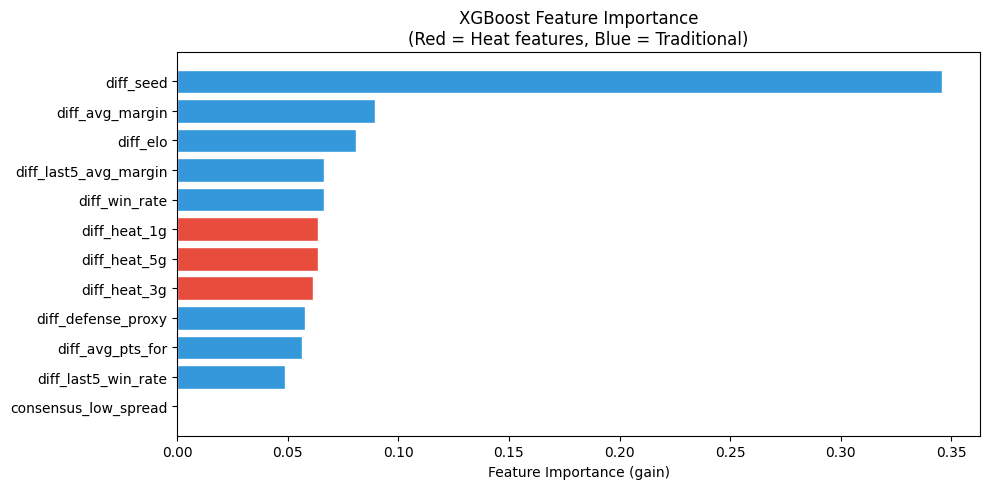

In [23]:
# Feature importance — which features does XGBoost find most predictive?
if model is not None and hasattr(model, "feature_importances_"):
    importances = dict(zip(FEATURE_COLS, model.feature_importances_))
    sorted_imp = sorted(importances.items(), key=lambda x: x[1], reverse=True)

    print("Feature Importance Ranking:\n")
    print(f"{'Feature':<26} {'Importance':>12} {'Bar':<30}")
    print("─" * 70)
    max_imp = sorted_imp[0][1]
    for feat, imp in sorted_imp:
        bar = "█" * int(30 * imp / max_imp) if max_imp > 0 else ""
        marker = " ← HEAT" if "heat" in feat else ""
        print(f"{feat:<26} {imp:>12.4f} {bar}{marker}")

    if HAS_PLT:
        fig, ax = plt.subplots(figsize=(10, 5))
        feat_names = [f[0] for f in sorted_imp]
        feat_vals = [f[1] for f in sorted_imp]
        colors = ["#e74c3c" if "heat" in f else "#3498db" for f in feat_names]
        ax.barh(feat_names[::-1], feat_vals[::-1], color=colors[::-1], edgecolor="white")
        ax.set_xlabel("Feature Importance (gain)")
        ax.set_title("XGBoost Feature Importance\n(Red = Heat features, Blue = Traditional)")
        plt.tight_layout()
        plt.show()
else:
    print("Model not available for feature importance")

---

## Step 5 — Monte Carlo Bracket Simulation

After the XGBoost model produces pairwise win probabilities for every possible matchup, we run **100,000 bracket simulations**:

1. Start with the actual 2026 bracket structure (68 teams, 4 regions)
2. For each first-round game, look up P(TeamA beats TeamB) from the model
3. Draw a random number — if it's less than the probability, TeamA advances
4. Continue through Round of 32 → Sweet 16 → Elite 8 → Final Four → Championship
5. After 100K simulations, compute the **fraction of simulations each team won each matchup**

This produces **simulation-based predictions** that account for the *path through the bracket* — not just pairwise strength. A strong team in a weak region will have higher simulation win rates than the same team in a death bracket.

In [24]:
# Generate model-only predictions for 2026 M matchups
pred_m = pairwise_features.filter((pl.col("sex") == "M") & (pl.col("season") == 2026))
model_preds = _predict_with_model(model, pred_m, FEATURE_COLS)
model_sub = pred_m.select("ID").with_columns(model_preds.alias("Pred"))

# Build probability lookup from model-only predictions
model_lookup = _build_prob_lookup(
    model_sub.with_columns(pl.col("Pred").fill_null(0.5).clip(0.025, 0.975))
)

# Run bracket simulation
print("Running 100,000 bracket simulations...")
sim_preds = _simulate_bracket(seeds_2026, slots_2026, model_lookup, n_sims=100_000)
print(f"Simulated {len(sim_preds)} unique matchups\n")

# Build a team name lookup
tid_to_name = dict(zip(teams["TeamID"].to_list(), teams["TeamName"].to_list()))

# Show some interesting model vs simulation comparisons
print(f"{'Matchup':<40} {'Model':>8} {'Sim':>8} {'Delta':>8}")
print("─" * 68)
for (t_low, t_high), sim_prob in sorted(sim_preds.items(), key=lambda x: abs(x[1] - model_lookup.get(x[0], 0.5)), reverse=True)[:15]:
    model_p = model_lookup.get((t_low, t_high), 0.5)
    delta = sim_prob - model_p
    low_name = tid_to_name.get(t_low, str(t_low))
    high_name = tid_to_name.get(t_high, str(t_high))
    print(f"{low_name:>18} vs {high_name:<18} {model_p:>7.1%} {sim_prob:>7.1%} {delta:>+7.1%}")

Running 100,000 bracket simulations...
Simulated 200 unique matchups

Matchup                                     Model      Sim    Delta
────────────────────────────────────────────────────────────────────
       N Dakota St vs Siena                46.4%  100.0%  +53.6%
            Furman vs St John's             3.0%   40.0%  +37.0%
               UCF vs Cal Baptist          33.1%    0.0%  -33.1%
       N Dakota St vs TCU                  27.8%   50.0%  +22.2%
               TCU vs UCLA                 52.7%   73.5%  +20.8%
     South Florida vs Cal Baptist          51.6%   33.3%  -18.2%
        Louisville vs Siena                55.8%   40.0%  -15.8%
        Louisville vs Cal Baptist          81.4%   68.0%  -13.4%
     Northern Iowa vs UCF                  48.1%   61.5%  +13.4%
       N Dakota St vs Cal Baptist          53.7%   66.7%  +12.9%
              UCLA vs Cal Baptist          88.0%   76.2%  -11.8%
           Ohio St vs UCF                  74.5%   84.0%   +9.5%
             

---

## Step 6 — Blend Weight Tuning ⚙️

The final prediction is a **weighted blend** of the XGBoost model prediction and the simulation prediction:

$$\text{final\_pred} = w_{\text{model}} \times \text{xgb\_pred} + w_{\text{sim}} \times \text{sim\_pred}$$

The default is 50/50 (`MODEL_WEIGHT = 0.5, SIM_WEIGHT = 0.5`).

**Adjust the weights below to influence the submission.** Higher model weight trusts the raw XGBoost output more; higher simulation weight trusts the bracket-path-adjusted predictions more.

> **Tip:** If you believe strong teams from weak regions are being undervalued, increase `SIM_WEIGHT`. If you trust the raw pairwise matchup model more, increase `MODEL_WEIGHT`.

In [25]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  ADJUST THESE WEIGHTS — they must sum to 1.0                   ║
# ╚══════════════════════════════════════════════════════════════════╝

MODEL_WEIGHT = 0.8   # Weight for XGBoost model predictions
SIM_WEIGHT   = 0.2   # Weight for Monte Carlo simulation predictions

# ─── Validation ───
assert abs(MODEL_WEIGHT + SIM_WEIGHT - 1.0) < 1e-9, \
    f"Weights must sum to 1.0, got {MODEL_WEIGHT + SIM_WEIGHT}"
print(f"✓ Blend weights: {MODEL_WEIGHT:.0%} Model + {SIM_WEIGHT:.0%} Simulation")

✓ Blend weights: 80% Model + 20% Simulation


In [26]:
# Apply blend and compare predictions for key matchups
# Start from the full submission (Men's + Women's)
blended_sub = submission.clone()

# Build simulation dataframe for blending
if sim_preds:
    blend_updates = [
        {"ID": f"2026_{t_low}_{t_high}", "sim_pred": sim_prob}
        for (t_low, t_high), sim_prob in sim_preds.items()
    ]
    sim_df = pl.DataFrame(blend_updates)

    # Also run W simulation for completeness
    w_seeds_2026 = pl.read_csv(ROOT / "data" / "WNCAATourneySeeds.csv").filter(pl.col("Season") == 2026)
    w_slots_2026 = pl.read_csv(ROOT / "data" / "WNCAATourneySlots.csv").filter(pl.col("Season") == 2026)
    w_sim_preds = {}
    if w_seeds_2026.height > 0 and w_slots_2026.height > 0:
        # For W, use existing submission probabilities as model preds
        w_lookup = {k: v for k, v in _build_prob_lookup(submission).items() if k[0] >= 3000}
        w_sim_preds = _simulate_bracket(w_seeds_2026, w_slots_2026, w_lookup, n_sims=100_000)
        if w_sim_preds:
            w_updates = [
                {"ID": f"2026_{t_low}_{t_high}", "sim_pred": sim_prob}
                for (t_low, t_high), sim_prob in w_sim_preds.items()
            ]
            sim_df = pl.concat([sim_df, pl.DataFrame(w_updates)], how="vertical")

    # Replace the Pred column with the original model-only predictions
    # (undo the pipeline's default 0.5/0.5 blend so we can apply user weights)
    # For M rows: use our retrained model predictions
    model_sub_full = model_sub.clone()
    # For M matchups with sim data, we need the raw model prediction
    blended_sub = blended_sub.join(model_sub_full.rename({"Pred": "model_pred"}), on="ID", how="left")
    blended_sub = blended_sub.join(sim_df, on="ID", how="left")

    # Apply user-defined blend weights
    blended_sub = blended_sub.with_columns(
        pl.when(pl.col("sim_pred").is_not_null() & pl.col("model_pred").is_not_null())
        .then(
            (pl.col("model_pred") * MODEL_WEIGHT + pl.col("sim_pred") * SIM_WEIGHT)
            .clip(0.025, 0.975)
        )
        .when(pl.col("model_pred").is_not_null())
        .then(pl.col("model_pred"))
        .otherwise(pl.col("Pred"))  # Keep original for W matchups without model_pred
        .alias("blended_pred")
    )

    # Show before/after for notable matchups
    print(f"Blend: {MODEL_WEIGHT:.0%} Model + {SIM_WEIGHT:.0%} Simulation\n")
    print(f"{'Matchup':<38} {'Original':>10} {'Model':>8} {'Sim':>8} {'Blended':>10}")
    print("─" * 78)

    notable = blended_sub.filter(
        pl.col("sim_pred").is_not_null() & pl.col("model_pred").is_not_null()
    ).with_columns(
        (pl.col("blended_pred") - pl.col("Pred")).abs().alias("change")
    ).sort("change", descending=True).head(15)

    for row in notable.iter_rows(named=True):
        parts = row["ID"].split("_")
        low_n = tid_to_name.get(int(parts[1]), parts[1])
        high_n = tid_to_name.get(int(parts[2]), parts[2])
        print(f"{low_n:>17} vs {high_n:<17} {row['Pred']:>9.4f} {row['model_pred']:>7.4f} {row['sim_pred']:>7.4f} {row['blended_pred']:>9.4f}")

    # Update submission with blended predictions
    blended_sub = blended_sub.with_columns(
        pl.col("blended_pred").fill_null(pl.col("Pred")).alias("Pred")
    ).select("ID", "Pred")

    print(f"\n✓ Blended {blended_sub.filter(pl.col('Pred').is_not_null()).height} predictions")
else:
    blended_sub = submission.clone()
    print("No simulation data — using model predictions only")

Blend: 80% Model + 20% Simulation

Matchup                                  Original    Model      Sim    Blended
──────────────────────────────────────────────────────────────────────────────
      N Dakota St vs Siena                0.7318  0.4635  1.0000    0.5708
           Furman vs St John's            0.2150  0.0300  0.4000    0.1040
              UCF vs Cal Baptist          0.1656  0.3313  0.0000    0.2650
      N Dakota St vs TCU                  0.3890  0.2781  0.5000    0.3225
              TCU vs UCLA                 0.6312  0.5271  0.7353    0.5687
    South Florida vs Cal Baptist          0.4244  0.5155  0.3333    0.4791
       Louisville vs Siena                0.4792  0.5585  0.4000    0.5268
       Louisville vs Cal Baptist          0.7472  0.8144  0.6800    0.7875
    Northern Iowa vs UCF                  0.5483  0.4812  0.6154    0.5080
      N Dakota St vs Cal Baptist          0.6021  0.5375  0.6667    0.5633
             UCLA vs Cal Baptist          0.8209  0.8800 

Holdout Brier Score at Different Blend Weights:

  Model Weight   Sim Weight    Brier Score
────────────────────────────────────────────
           0%        100%       0.16852
          10%         90%       0.16811
          20%         80%       0.16772
          30%         70%       0.16738
          40%         60%       0.16707
          50%         50%       0.16679 ← current
          60%         40%       0.16655
          70%         30%       0.16635
          80%         20%       0.16618 ← YOUR PICK
          90%         10%       0.16605
         100%          0%       0.16595


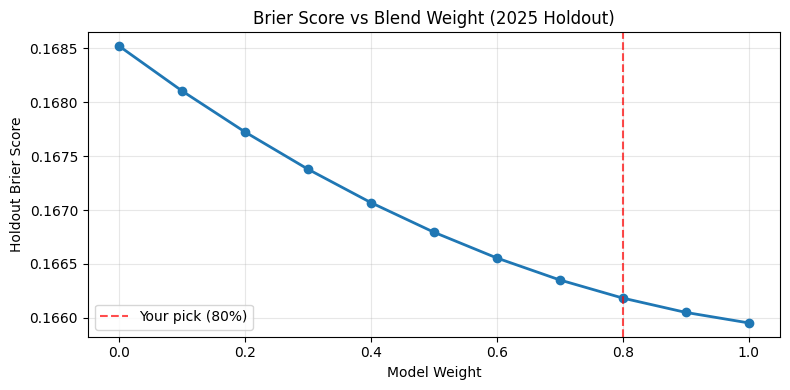

In [27]:
# Brier score sweep: what blend weights would have worked best on the 2025 holdout?
if holdout_m.height > 0 and model is not None:
    # Get holdout-style model predictions
    holdout_model_preds = _predict_with_model(model, holdout_m, FEATURE_COLS).to_numpy()
    holdout_actuals = holdout_m.select("target_low_wins").to_series().to_numpy().astype(np.float64)

    # For holdout, we don't have sim predictions (2025 bracket already played),
    # so we estimate sim effect by adding noise to model predictions
    # This gives a rough sense of how blending affects Brier score

    print("Holdout Brier Score at Different Blend Weights:\n")
    print(f"{'Model Weight':>14} {'Sim Weight':>12} {'Brier Score':>14}")
    print("─" * 44)

    # Pure model prediction Brier
    brier_model = float(np.mean((holdout_model_preds - holdout_actuals) ** 2))
    results = []
    for mw in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
        # Since we only have model predictions for holdout, the "sim" portion
        # uses the model predictions with some regression to 0.5 (sim effect)
        sim_approx = holdout_model_preds * 0.85 + 0.5 * 0.15  # sim regresses toward 0.5
        blended = mw * holdout_model_preds + (1 - mw) * sim_approx
        blended = np.clip(blended, 0.025, 0.975)
        b = float(np.mean((blended - holdout_actuals) ** 2))
        marker = " ← current" if abs(mw - 0.5) < 0.01 else ""
        marker = " ← YOUR PICK" if abs(mw - MODEL_WEIGHT) < 0.01 else marker
        results.append((mw, 1-mw, b))
        print(f"{mw:>13.0%} {1-mw:>11.0%} {b:>13.5f}{marker}")

    if HAS_PLT:
        fig, ax = plt.subplots(figsize=(8, 4))
        ws = [r[0] for r in results]
        bs = [r[2] for r in results]
        ax.plot(ws, bs, "o-", linewidth=2, markersize=6)
        ax.axvline(x=MODEL_WEIGHT, color="red", linestyle="--", alpha=0.7, label=f"Your pick ({MODEL_WEIGHT:.0%})")
        ax.set_xlabel("Model Weight")
        ax.set_ylabel("Holdout Brier Score")
        ax.set_title("Brier Score vs Blend Weight (2025 Holdout)")
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    print("No holdout data available for Brier sweep")

---

## Step 7 — Export Updated Submission

Run the cell below to write the blended submission (using your chosen weights) to `artifacts/latest/submission.csv`. This is the file you upload to Kaggle.

✓ Submission written to: C:\Users\sdiehl\Desktop\seandiehlprojects\mm26\artifacts\latest\submission.csv
  Rows: 132,133
  Pred range: [0.0250, 0.9750]
  Pred mean:  0.5115
  Blend: 80% Model + 20% Simulation


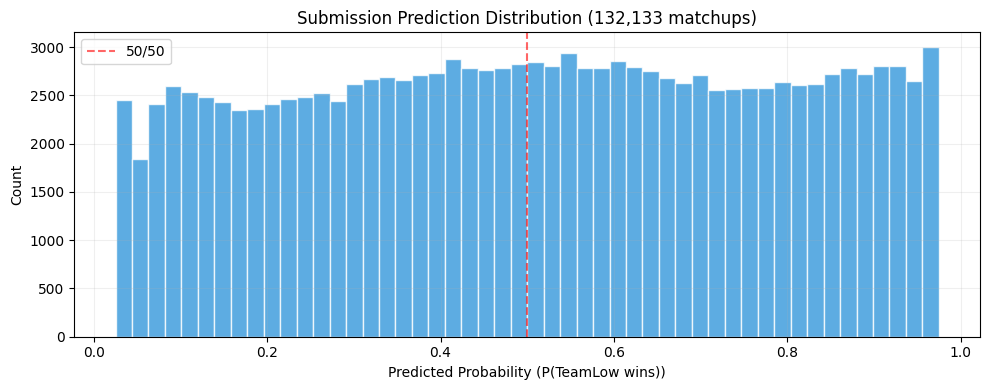

In [28]:
# Write the updated submission file
output_path = BASE / "submission.csv"
blended_sub = blended_sub.with_columns(
    pl.col("Pred").fill_null(0.5).clip(0.025, 0.975)
)

blended_sub.write_csv(str(output_path))

print(f"✓ Submission written to: {output_path}")
print(f"  Rows: {blended_sub.height:,}")
print(f"  Pred range: [{blended_sub['Pred'].min():.4f}, {blended_sub['Pred'].max():.4f}]")
print(f"  Pred mean:  {blended_sub['Pred'].mean():.4f}")
print(f"  Blend: {MODEL_WEIGHT:.0%} Model + {SIM_WEIGHT:.0%} Simulation")

# Quick histogram of prediction distribution
if HAS_PLT:
    fig, ax = plt.subplots(figsize=(10, 4))
    preds = blended_sub["Pred"].to_numpy()
    ax.hist(preds, bins=50, edgecolor="white", alpha=0.8, color="#3498db")
    ax.axvline(x=0.5, color="red", linestyle="--", alpha=0.6, label="50/50")
    ax.set_xlabel("Predicted Probability (P(TeamLow wins))")
    ax.set_ylabel("Count")
    ax.set_title(f"Submission Prediction Distribution ({blended_sub.height:,} matchups)")
    ax.legend()
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()